In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

WD = Path(
    "/blue/juannanzhou/arindam.sarkar/BB-QTL_HT/"
    "7_HIPHOP_validation/Single-dose_QTL_randomized"
)

INPUT_FILE = (
    WD / "input" / "all_plates_input_long.tsv"
)

# Change this to QTL2 for the second analysis.
QTL_TO_PLOT = "QTL2"

# Separate folder prevents QTL2 from overwriting QTL1.
RESULTS_DIR = (
    WD
    / "blank_corrected_results"
    / QTL_TO_PLOT
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OD_COLUMN = "OD600_blank_corrected"

CONTROL = "0x"
TREATMENT = "1x"

ERROR_MODE = "sem"

PLATE_TO_CONDITION = {
    "CHR15_C_0x": CONTROL,
    "CHR15_T_1x": TREATMENT,
}

In [12]:
# Global plotting style
plt.rcParams.update({
    # General font
    "font.size": 14,
    "font.weight": "bold",

    # Axis titles and labels
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",

    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Legend
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,

    # Figure output
    "figure.titlesize": 18,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print("Global plotting style applied.")

Global plotting style applied.


In [13]:
df = pd.read_csv(
    INPUT_FILE,
    sep="\t",
    dtype={"sample_id": str},
)

required_columns = {
    "plate",
    "sample_id",
    "gene",
    "replicate",
    "well",
    "OD600_raw",
    "blank_mean",
    "OD600_blank_corrected",
}

missing = required_columns - set(df.columns)

if missing:
    raise ValueError(
        f"Missing required columns: {sorted(missing)}"
    )

df[OD_COLUMN] = pd.to_numeric(
    df[OD_COLUMN],
    errors="coerce",
)

if df[OD_COLUMN].isna().any():
    raise ValueError(
        "Missing or non-numeric blank-corrected OD600 values found."
    )

df["condition"] = df["plate"].map(
    PLATE_TO_CONDITION
)

unmapped = sorted(
    df.loc[df["condition"].isna(), "plate"].unique()
)

if unmapped:
    raise ValueError(
        "Add these plates to PLATE_TO_CONDITION: "
        f"{unmapped}"
    )

df["condition"] = pd.Categorical(
    df["condition"],
    categories=[CONTROL, TREATMENT],
    ordered=True,
)

# Confirm the correction stored in the input file.
recalculated = (
    df["OD600_raw"] - df["blank_mean"]
)

if not np.allclose(
    df["OD600_blank_corrected"],
    recalculated,
    rtol=1e-5,
    atol=1e-5,
    equal_nan=True,
):
    raise ValueError(
        "OD600_blank_corrected does not equal "
        "OD600_raw - blank_mean."
    )

blank_qc = (
    df.groupby("plate", as_index=False)
    .agg(
        blank_mean=("blank_mean", "first"),
        minimum_corrected_OD=(
            OD_COLUMN,
            "min",
        ),
        maximum_corrected_OD=(
            OD_COLUMN,
            "max",
        ),
    )
)

display(blank_qc)

print(f"Measurements: {len(df):,}")
print(f"Strains:      {df['sample_id'].nunique():,}")
print(f"Plates:       {df['plate'].nunique():,}")

,plate,blank_mean,minimum_corrected_OD,maximum_corrected_OD
0,CHR15_C_0x,0.093625,0.717375,1.409370
1,CHR15_T_1x,0.093875,-0.001875,0.783125


Measurements: 160
Strains:      8
Plates:       2


In [14]:
if "qtl" not in df.columns:
    raise ValueError(
        "The input file does not contain a qtl column. "
        "Rerun the updated input-generation notebook."
    )

available_qtls = sorted(
    df["qtl"]
    .dropna()
    .unique()
)

print(
    "Available QTLs:",
    available_qtls,
)

if QTL_TO_PLOT not in available_qtls:
    raise ValueError(
        f"{QTL_TO_PLOT} was not found. "
        f"Available QTLs: {available_qtls}"
    )

df = df.loc[
    df["qtl"] == QTL_TO_PLOT
].copy()

if df.empty:
    raise ValueError(
        f"No measurements found for {QTL_TO_PLOT}."
    )

print(
    f"Plotting {QTL_TO_PLOT}: "
    f"{df['sample_id'].nunique()} strains, "
    f"{len(df)} measurements."
)

Available QTLs: ['QTL1', 'QTL2']
Plotting QTL2: 4 strains, 80 measurements.


In [15]:
od_summary = (
    df.groupby(
        ["sample_id", "gene", "condition"],
        observed=True,
        as_index=False,
    )
    .agg(
        mean_OD600=(OD_COLUMN, "mean"),
        sd_OD600=(OD_COLUMN, "std"),
        n=(OD_COLUMN, "size"),
    )
)

od_summary["sem_OD600"] = (
    od_summary["sd_OD600"]
    / np.sqrt(od_summary["n"])
)

if ERROR_MODE == "sem":
    od_summary["OD600_error"] = (
        od_summary["sem_OD600"]
    )
    error_label = "SEM"

elif ERROR_MODE == "ci95":
    od_summary["OD600_error"] = (
        1.96 * od_summary["sem_OD600"]
    )
    error_label = "95% CI"

else:
    raise ValueError(
        "ERROR_MODE must be 'sem' or 'ci95'."
    )

display(od_summary)

,sample_id,gene,condition,mean_OD600,sd_OD600,n,sem_OD600,OD600_error
0,5,DUF1,0x,0.950774,0.171679,10,0.054290,0.054290
1,5,DUF1,1x,0.658825,0.232971,10,0.073672,0.073672
2,6,HAL9,0x,0.944575,0.141295,10,0.044682,0.044682
3,6,HAL9,1x,0.609125,0.191028,10,0.060408,0.060408
4,7,MPD2,0x,0.864475,0.072791,10,0.023019,0.023019
5,7,MPD2,1x,0.683525,0.083499,10,0.026405,0.026405
6,8,MSH2,0x,0.900775,0.082139,10,0.025975,0.025975
7,8,MSH2,1x,0.603825,0.066396,10,0.020996,0.020996


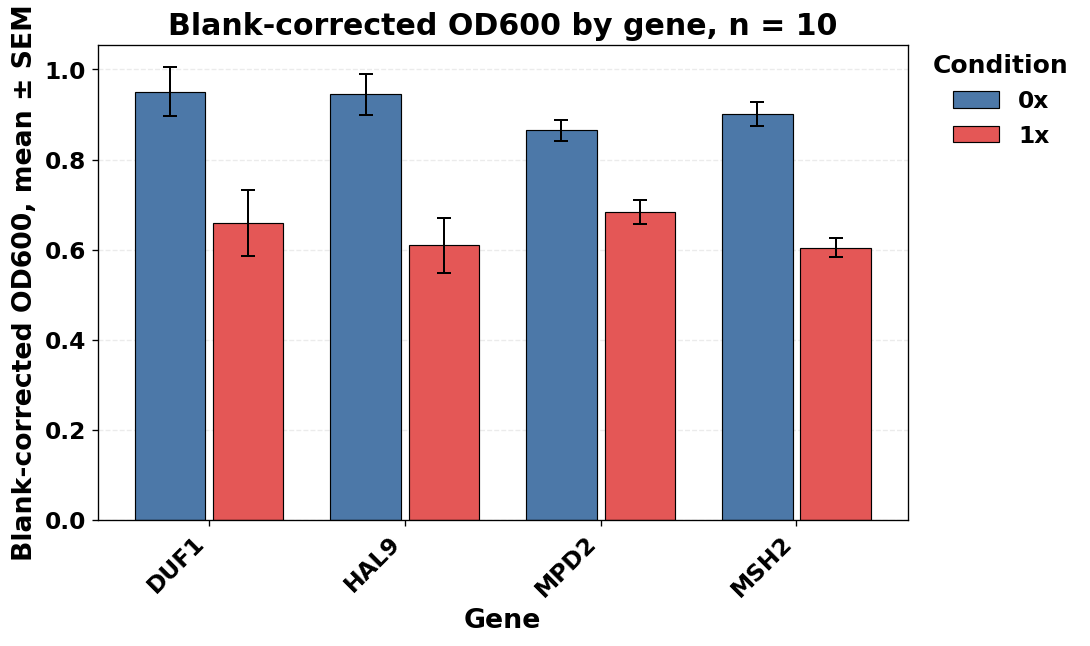

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/QTL2/blank_corrected_OD600_barplot.png


In [16]:
strain_order = (
    df[["sample_id", "gene"]]
    .drop_duplicates()
    .sort_values("sample_id", kind="stable")
    .reset_index(drop=True)
)

conditions = [CONTROL, TREATMENT]

colors = {
    CONTROL: "#4C78A8",
    TREATMENT: "#E45756",
}

x = np.arange(len(strain_order))

number_of_conditions = len(conditions)
bar_width = 0.8 / number_of_conditions

offsets = (
    np.arange(number_of_conditions)
    - (number_of_conditions - 1) / 2
) * bar_width

fig, ax = plt.subplots(
    figsize=(
        max(10, 0.75 * len(strain_order) + 2),
        6,
    )
)

for offset, condition in zip(
    offsets,
    conditions,
):
    plot_data = (
        od_summary.loc[
            od_summary["condition"] == condition
        ]
        .set_index("sample_id")
        .reindex(strain_order["sample_id"])
    )

    ax.bar(
        x + offset,
        plot_data["mean_OD600"],
        width=bar_width * 0.9,
        yerr=plot_data["OD600_error"],
        capsize=4,
        color=colors[condition],
        edgecolor="black",
        linewidth=0.7,
        label=condition,
        error_kw={
            "elinewidth": 1.2,
            "capthick": 1.2,
        },
    )

ax.set_xticks(x)

ax.set_xticklabels(
    strain_order["gene"],
    rotation=45,
    ha="right",
)

plt.setp(
    ax.get_xticklabels(),
    fontweight="bold",
)

plt.setp(
    ax.get_yticklabels(),
    fontweight="bold",
)

ax.set_xlabel("Gene")

ax.set_ylabel(
    f"Blank-corrected OD600, mean ± {error_label}"
)

replicate_numbers = (
    od_summary["n"]
    .dropna()
    .astype(int)
    .unique()
)

if len(replicate_numbers) == 1:
    n_title = str(replicate_numbers[0])
else:
    n_title = (
        f"{replicate_numbers.min()}–"
        f"{replicate_numbers.max()}"
    )

ax.set_title(
    f"Blank-corrected OD600 by gene, n = {n_title}"
)

# Place legend completely outside the plotting area.
legend = ax.legend(
    title="Condition",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=False,
)

legend.get_title().set_fontweight("bold")

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--",
)

ax.set_axisbelow(True)

# Reserve space on the right for the outside legend.
fig.subplots_adjust(
    right=0.80,
    bottom=0.22,
    top=0.88,
)

od_plot_path = (
    RESULTS_DIR / "blank_corrected_OD600_barplot.png"
)

fig.savefig(
    od_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {od_plot_path}")

In [17]:
od_wide = od_summary.pivot(
    index=["sample_id", "gene"],
    columns="condition",
    values=["mean_OD600", "sem_OD600"],
)

fd_summary = od_wide.index.to_frame(
    index=False
)

fd_summary["OD600_0x"] = (
    od_wide[("mean_OD600", CONTROL)]
    .to_numpy()
)

fd_summary["OD600_1x"] = (
    od_wide[("mean_OD600", TREATMENT)]
    .to_numpy()
)

fd_summary["SEM_0x"] = (
    od_wide[("sem_OD600", CONTROL)]
    .to_numpy()
)

fd_summary["SEM_1x"] = (
    od_wide[("sem_OD600", TREATMENT)]
    .to_numpy()
)

nonpositive = (
    (fd_summary["OD600_0x"] <= 0)
    | (fd_summary["OD600_1x"] <= 0)
)

if nonpositive.any():
    display(fd_summary.loc[nonpositive])

    raise ValueError(
        "FD cannot be calculated when a strain-level "
        "mean OD600 is zero or negative. Do not add a "
        "pseudocount without documenting and justifying it."
    )

fd_summary["FD"] = np.log2(
    fd_summary["OD600_1x"]
    / fd_summary["OD600_0x"]
)

# Propagated SEM for log2(T/C), assuming independent
# control and treatment measurements.
fd_summary["FD_SEM"] = (
    np.sqrt(
        (
            fd_summary["SEM_1x"]
            / fd_summary["OD600_1x"]
        ) ** 2
        +
        (
            fd_summary["SEM_0x"]
            / fd_summary["OD600_0x"]
        ) ** 2
    )
    / np.log(2)
)

if ERROR_MODE == "sem":
    fd_summary["FD_error"] = (
        fd_summary["FD_SEM"]
    )

elif ERROR_MODE == "ci95":
    fd_summary["FD_error"] = (
        1.96 * fd_summary["FD_SEM"]
    )

display(fd_summary)

,sample_id,gene,OD600_0x,OD600_1x,SEM_0x,SEM_1x,FD,FD_SEM,FD_error
0,5,DUF1,0.950774,0.658825,0.054290,0.073672,-0.529208,0.181142,0.181142
1,6,HAL9,0.944575,0.609125,0.044682,0.060408,-0.632926,0.158518,0.158518
2,7,MPD2,0.864475,0.683525,0.023019,0.026405,-0.338830,0.067688,0.067688
3,8,MSH2,0.900775,0.603825,0.025975,0.020996,-0.577035,0.065171,0.065171


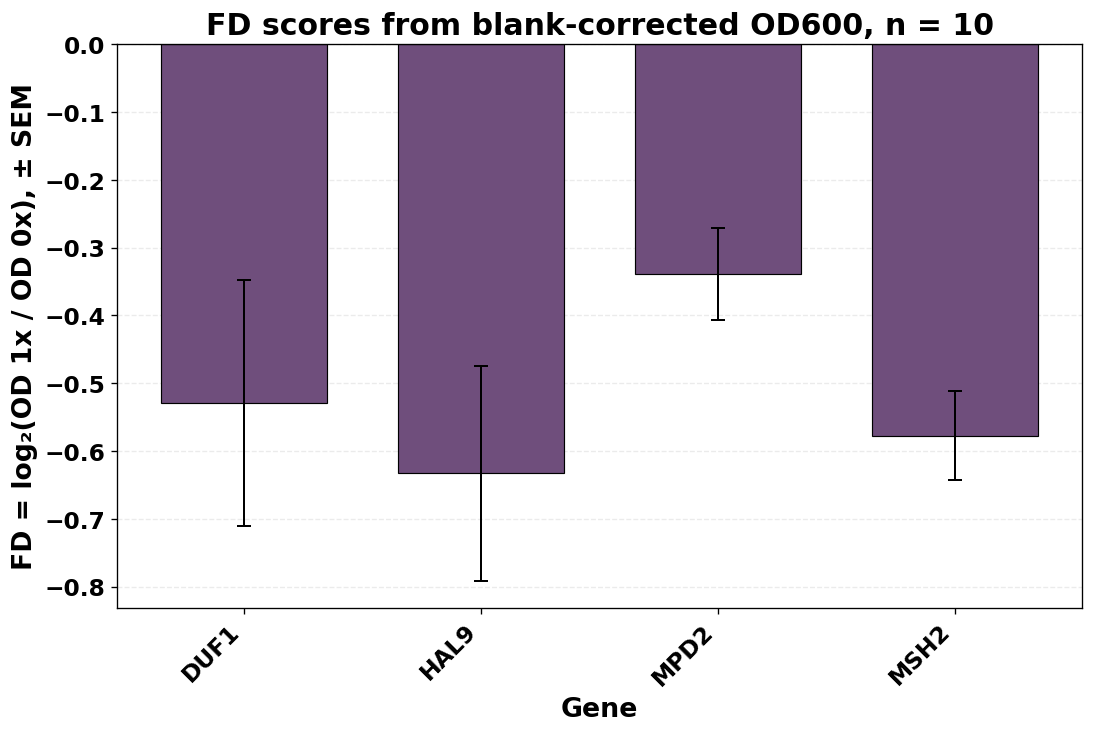

Saved: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/QTL2/blank_corrected_FD_barplot.png


In [18]:
fd_summary = (
    strain_order
    .merge(
        fd_summary,
        on=["sample_id", "gene"],
        how="left",
        validate="one_to_one",
    )
)

x = np.arange(len(fd_summary))

fig, ax = plt.subplots(
    figsize=(
        max(9, 0.75 * len(fd_summary)),
        6,
    ),
    constrained_layout=True,
)

ax.bar(
    x,
    fd_summary["FD"],
    width=0.7,
    yerr=fd_summary["FD_error"],
    capsize=4,
    color="#6F4E7C",
    edgecolor="black",
    linewidth=0.7,
    error_kw={
        "elinewidth": 1.2,
        "capthick": 1.2,
    },
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

ax.set_xticks(x)

ax.set_xticklabels(
    fd_summary["gene"],
    rotation=45,
    ha="right",
)

ax.set_xlabel("Gene")

ax.set_ylabel(
    f"FD = log₂(OD 1x / OD 0x), ± {error_label}"
)

ax.set_title(
    f"FD scores from blank-corrected OD600, n = {n_title}"
)

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle="--",
)

ax.set_axisbelow(True)

fd_plot_path = (
    RESULTS_DIR / "blank_corrected_FD_barplot.png"
)

fig.savefig(
    fd_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {fd_plot_path}")

In [19]:
od_summary.to_csv(
    RESULTS_DIR / "blank_corrected_OD600_summary.tsv",
    sep="\t",
    index=False,
    float_format="%.6g",
)

fd_summary.to_csv(
    RESULTS_DIR / "blank_corrected_FD_summary.tsv",
    sep="\t",
    index=False,
    float_format="%.6g",
)

print(f"Results saved under: {RESULTS_DIR}")

Results saved under: /blue/juannanzhou/arindam.sarkar/BB-QTL_HT/7_HIPHOP_validation/Single-dose_QTL_randomized/blank_corrected_results/QTL2
